In [1]:
import sys
from pathlib import Path

def find_repo_root_local(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "src").is_dir() and (candidate / "tools").is_dir():
            return candidate
    raise RuntimeError("Could not locate the repository root.")

REPO_ROOT = find_repo_root_local(Path.cwd())
SRC_DIR = REPO_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import glob
import importlib
import json
import math
import random

import hypernetx as hnx
import matplotlib.pyplot as plt
import numpy as np
import ot
import pandas
import pd
import plotly.express as px
import plotly.graph_objects as go
import scipy as sp
import seaborn as sb
import sklearn as sk
import sklearn.decomposition
import topo_util
import tpot
from entropy import hyper_edge_entropy, hyper_graph_entropy, hypergraph_shannon_entropy, persist_entropy
from experiment_utils import align_2d as align
from experiment_utils import compute_coot_ot_gw_distances, convex_point, geodesic_distances, get_affinities, reflect_points as reflect, zscore
from plotly.offline import download_plotlyjs, init_notebook_mode, iplot, plot
from plotly.subplots import make_subplots
from synthetic_data import generate_bistable_dataset, generate_full_dataset, sample_1to2, sample_rvp_reproducible
from topo_util import noisy_circle, noisy_ellipses
from tqdm import tqdm

init_notebook_mode(connected=True)

import topfmain


/opt/anaconda3/envs/tpot/lib/python3.9/site-packages/kaleido/_sync_server.py:11: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.




/opt/anaconda3/envs/tpot/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning:

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html



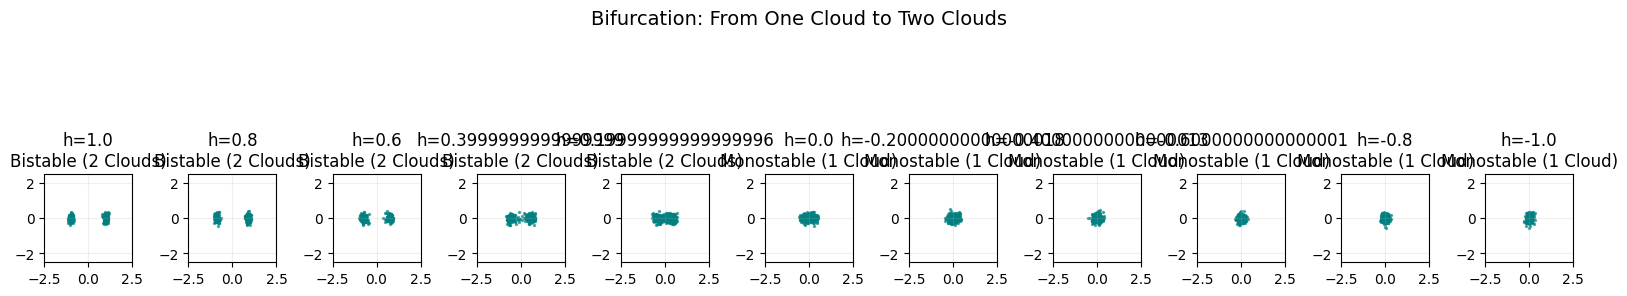

In [2]:
MAIN_SEED = 42
h_values = np.linspace(-1, 1, 10)

plt.figure(figsize=(15, 3.5))
for idx, h_val in enumerate(h_values):
    current_seed = MAIN_SEED + idx
    points = sample_1to2(h_val, n_samples=200, T=0.001, seed=current_seed)
    ax = plt.subplot(1, 10, idx + 1)
    ax.scatter(points[:, 0], points[:, 1], s=2, alpha=0.6, c='royalblue')
    ax.set_title(f'h={h_val:.1f}\n(Seed={current_seed})')
    ax.set_xlim(-2.5, 2.5)
    ax.set_ylim(-2.5, 2.5)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

dataset = generate_bistable_dataset(seed=42)
print(f"Dataset shape: {dataset.shape}")


In [3]:
h_index = np.unique(dataset[:,0])[::-1]
point_clouds = []
for h in h_index:
    mask = dataset[:,0] == h
    X_t = dataset[mask][:,1:]
    point_clouds.append(X_t)

import numpy as np
import plotly.express as px

frames_list = []

for i, points in enumerate(point_clouds):
    pts_array = np.array(points)

    df = pandas.DataFrame({
        'x': pts_array[:, 0],
        'y': pts_array[:, 1],
        'frame': i
    })
    frames_list.append(df)

DF = pandas.concat(frames_list, ignore_index=True)

fig = px.scatter(
    DF,
    x="x",
    y="y",
    animation_frame="frame",
)

fig.update_traces(
    marker=dict(size=3, color='royalblue'), # 在这里统一设置大小和颜色
    selector=dict(mode='markers')
)

fig.layout.updatemenus[0].buttons[0].args[1]['frame']['duration'] = 30
fig.layout.updatemenus[0].buttons[0].args[1]['transition']['duration'] = 5

fig.update_yaxes(scaleanchor="x", scaleratio=1)
fig.update_layout(
    width=600,
    height=500,
    showlegend=False # 纯点云可视化通常不需要图例
)

fig.show()


In [4]:
h_index = np.unique(dataset[:,0])[::-1]
indices = np.linspace(0, len(h_index) - 1, num=4, dtype=int)
h_n_index = [h_index[i] for i in indices]
gt_points = []

for h in h_n_index:
    mask = dataset[:,0] == h
    X_t = dataset[mask][:,1:]
    gt_points.append(X_t)
A = gt_points[0]


In [5]:
C_v0 = get_affinities(A)
p = ot.unif(len(A))
topf_all = [topfmain.topf(x, return_dict = True, complex_type = 'rips', fixed_num_features = [0,5]) for x in tqdm([A])]
y0 = topf_all[0][0]
df0 = [pandas.DataFrame({"b" : x[1]['birth_times'], "d" : x[1]['death_times'], "pers" : np.array(x[1]['death_times']) - np.array(x[1]['birth_times'])}) for x in topf_all]
p_spt = df0[0].iloc[:, :2].values


100%|██████████| 1/1 [00:09<00:00,  9.89s/it]


In [6]:
from sklearn.metrics import pairwise_distances
from sklearn.manifold import MDS
from matplotlib.collections import LineCollection
from sklearn import manifold
from sklearn.metrics import euclidean_distances
from scipy.spatial.transform import Rotation as R
import warnings
warnings.filterwarnings("ignore")
C_vt_1 = get_affinities(A) # C matrix at t-1
pt_1 = ot.unif(len(A))
yt_1 = y0
p_spt_1 = p_spt
X_t_1 = A
all_models_alligned = [A]

for (X_t, h) in zip(gt_points[1:], h_n_index[1:]):
    print(f'Processing geodesics ended at h={h}')
    C_vt = get_affinities(X_t)
    q = ot.unif(len(X_t))
    topf_all = [topfmain.topf(x, return_dict = True, complex_type = 'rips', fixed_num_features = [0,4]) for x in tqdm([X_t])]
    yt = topf_all[0][0]
    dft = [pandas.DataFrame({"b" : x[1]['birth_times'], "d" : x[1]['death_times'], "pers" : np.array(x[1]['death_times']) - np.array(x[1]['birth_times'])}) for x in topf_all]
    q_spt = dft[0].iloc[:, :2].values

    pt_1, q = pd.augmented_weights(p_spt_1, q_spt)
    C_t = pd.augmented_cost(p_spt_1, q_spt)
    C_pd_t = pd.augmented_cost(p_spt_1, q_spt); #C_pd_t /= C_pd_t.mean()

    alpha = 0.5
    beta = 1

    wt_1 = ot.unif(yt_1.shape[0])
    wt = ot.unif(yt.shape[0])
    vt_1 = pt_1
    vt = q
    pi_s_t, pi_f_t, _, = tpot.TPOT(yt_1, yt, wt_1, wt, vt_1, vt,
                            C_vt_1, C_vt, C_pd_t,
                            beta = beta, alpha = alpha, print_iter = 40, iter = 100,
                            solver = "sinkhorn",
                            eps_s = 0.003, eps_f = 0.01, numItermax = 2500)

    P = (pi_s_t / pi_s_t.sum(axis=-1)[:, np.newaxis])
    Q = (pi_f_t[:-1, :-1] / pi_f_t[:-1, :-1].sum(axis=-1)[:, np.newaxis])
    Q[np.isnan(Q)] = 0

    matching = np.array(np.where(ot.emd(wt_1, wt, pi_s_t.max()-pi_s_t) > 0)).T # round coupling
    num_frames = 18
    x1 = np.linspace(0, 1, num_frames, endpoint=True)
    matrices = [geodesic_distances(X_t_1,X_t,t, matching) for t in x1]
    convex_points = np.array([convex_point(X_t_1,X_t,t, matching) for t in x1])

    model = MDS(n_components=2, dissimilarity='precomputed', random_state=2002)
    models = []
    out = model.fit(matrices[0]).embedding_
    pos = align(out, convex_points[0])
    models_alligned = [pos]
    for ii in range(1, num_frames):
        true = convex_points[ii]
        out = model.fit(matrices[ii]).embedding_
        pos = align(out, true)
        rpos = reflect(pos)
        if np.linalg.norm(models_alligned[-1] - pos) >  np.linalg.norm(models_alligned[-1] - rpos):
            pos = rpos
        models.append(out)
        models_alligned.append(pos)
    for alligned_points in models_alligned[1:]:
        all_models_alligned.append(alligned_points)

    X_t_1 = X_t
    C_vt_1 = C_vt
    yt_1 = yt
    p_spt_1 = q_spt


Processing geodesics ended at h=0.36


100%|██████████| 1/1 [00:09<00:00,  9.65s/it]


Iteration 0,	 obj = 0.1079848166539361,	 obj_terms = {'coot': 0.029716404992835437, 'ot': 0.0005366417702028512, 'gw': 0.0777317698908978}
Iteration 40,	 obj = 0.02666607470777215,	 obj_terms = {'coot': 0.021396890193183467, 'ot': 0.0004835790503398263, 'gw': 0.004785605464248856}
Iteration 80,	 obj = 0.026666074709381905,	 obj_terms = {'coot': 0.021396890191620686, 'ot': 0.00048357905302575445, 'gw': 0.004785605464735466}
Processing geodesics ended at h=-0.32000000000000006


100%|██████████| 1/1 [00:09<00:00,  9.95s/it]


Iteration 0,	 obj = 0.08271723107668483,	 obj_terms = {'coot': 0.02981564108905433, 'ot': 0.0008161996959880483, 'gw': 0.05208539029164244}
Iteration 40,	 obj = 0.04782064358942864,	 obj_terms = {'coot': 0.012555323332775346, 'ot': 0.0010980329300371947, 'gw': 0.0341672873266161}
is_converged, obj = 0.047820670516167896, obj_new = 0.04782067073623301
Processing geodesics ended at h=-1.0


100%|██████████| 1/1 [00:09<00:00,  9.73s/it]


Iteration 0,	 obj = 0.0607821655368677,	 obj_terms = {'coot': 0.03417872523228169, 'ot': 0.0006604011392782578, 'gw': 0.025943039165307755}
Iteration 40,	 obj = 0.04440362350263826,	 obj_terms = {'coot': 0.03189209321987696, 'ot': 0.0003803739314438414, 'gw': 0.012131156351317457}
Iteration 80,	 obj = 0.04441208511716042,	 obj_terms = {'coot': 0.03188830503828398, 'ot': 0.0003804638931451013, 'gw': 0.012143316185731338}


In [7]:
import numpy as np
from coot import dot, eta


In [8]:
coot_values = []
ot_values = []
gw_values = []
total_values = []
pe_values = []#persistent entropy
hge_values = []#hyper graph entropy(new defined)
hse_values = []#hypergraph shannon entropy
hee_values = []#hyperedge entropy
geodesic_pd = []#PD on the geodesic
sym_values = []#symmetric hypergraph entropy
num_points = len(A)

para_alpha = 0.5

for i in range(0, len(all_models_alligned)):
    G = all_models_alligned[i]
    C_vt = get_affinities(G)
    g = ot.unif(len(G))
    topf_all = [topfmain.topf(x, return_dict = True, complex_type = 'rips', fixed_num_features = [0,4]) for x in tqdm([G])]
    yt = topf_all[0][0]
    dft = [pandas.DataFrame({"b" : x[1]['birth_times'], "d" : x[1]['death_times'], "pers" : np.array(x[1]['death_times']) - np.array(x[1]['birth_times'])}) for x in topf_all]
    g_spt = dft[0].iloc[:, :2].values
    p, g = pd.augmented_weights(p_spt, g_spt)
    C = pd.augmented_cost(p_spt, g_spt)
    C_pd = pd.augmented_cost(p_spt, g_spt); #C_pd /= C_pd.mean()

    alpha = 0.5
    beta = 1

    w0 = ot.unif(y0.shape[0])
    wt = ot.unif(yt.shape[0])
    v0 = p
    vt = g
    pi_s, pi_f, _, = tpot.TPOT(y0, yt, w0, wt, v0, vt,
                            C_v0, C_vt, C_pd,
                            beta = beta, alpha = alpha, print_iter = 50, iter = 100,
                            solver = "sinkhorn",
                            eps_s = 0.003, eps_f = 0.01, numItermax = 2500)

    P = (pi_s / pi_s.sum(axis=-1)[:, np.newaxis])
    Q = (pi_f[:-1, :-1] / pi_f[:-1, :-1].sum(axis=-1)[:, np.newaxis])
    Q[np.isnan(Q)] = 0

    value = compute_coot_ot_gw_distances(y0, yt,
                           C_v0, C_vt, C_pd,
                           pi_s, pi_f,
                           alpha = alpha, beta=beta)
    coot_values.append(value[0]/beta)
    ot_values.append(value[1]/(1-alpha))
    gw_values.append(value[2]/alpha)
    total_values.append(value[2] + value[1] + value[0])

    pe_value = persist_entropy(g_spt)
    hge_value = hyper_graph_entropy(yt)
    hee_value = hyper_edge_entropy(yt)
    hse_value = hypergraph_shannon_entropy(yt)

    geodesic_pd.append(g_spt)

    pe_values.append(pe_value)
    hge_values.append(hge_value)
    hee_values.append(hee_value)
    hse_values.append(hse_value)
    sym_values.append(para_alpha * hge_value + (1-para_alpha) * hee_value)

    print(f'Time Stamp:{i}')


100%|██████████| 1/1 [00:08<00:00,  8.85s/it]


Iteration 0,	 obj = 0.11507054602694058,	 obj_terms = {'coot': 0.02765152259109578, 'ot': 9.900223209336356e-05, 'gw': 0.08732002120375144}
is_converged, obj = 0.010229960262133691, obj_new = 0.010229961010840477
Time Stamp:0


100%|██████████| 1/1 [00:08<00:00,  8.79s/it]


Iteration 0,	 obj = 0.11447506071112062,	 obj_terms = {'coot': 0.027575237331588988, 'ot': 0.00012062767297317274, 'gw': 0.08677919570655847}
is_converged, obj = 0.009830374284828169, obj_new = 0.009830373420573881
Time Stamp:1


100%|██████████| 1/1 [00:08<00:00,  8.52s/it]


...

Iteration 0,	 obj = 0.09358400255232532,	 obj_terms = {'coot': 0.02850096828659169, 'ot': 0.0005070183232228012, 'gw': 0.06457601594251083}
is_converged, obj = 0.04860564288827779, obj_new = 0.04860564310504505
Time Stamp:49


100%|██████████| 1/1 [00:12<00:00, 12.27s/it]


Iteration 0,	 obj = 0.09770909345830686,	 obj_terms = {'coot': 0.03271604119519997, 'ot': 0.0005029298766302256, 'gw': 0.06449012238647667}
is_converged, obj = 0.049991727377018236, obj_new = 0.04999172799150073
Time Stamp:50


100%|██████████| 1/1 [00:09<00:00,  9.45s/it]


Iteration 0,	 obj = 0.09779095249974044,	 obj_terms = {'coot': 0.033094024675359046, 'ot': 0.00010013398807173378, 'gw': 0.06459679383630966}
is_converged, obj = 0.050471448356591855, obj_new = 0.050471448056522844
Time Stamp:51


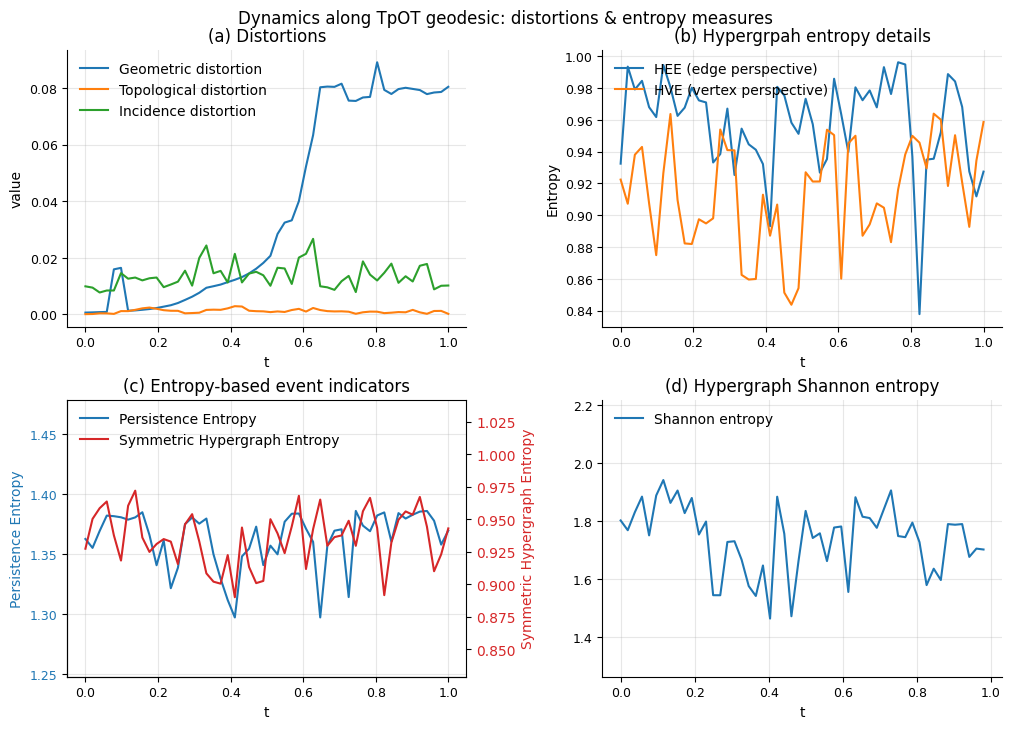

In [9]:
hse_rate = [hse_values[i] - hse_values[i-1] for i in range(1,len(hse_values))]
hge_rate = [hge_values[i] - hge_values[i-1] for i in range(1,len(hge_values))]

import numpy as np
import matplotlib.pyplot as plt

num_frames = len(coot_values)
x = np.arange(len(ot_values))

geom = np.asarray(gw_values)        # 几何（你原来的 gw_values / geom Values）
topo = np.asarray(ot_values)         # 拓扑
hyper = np.asarray(coot_values)      # 超图/Incidence（你原来 coot 或类似）

PE = np.asarray(pe_values)           # Persistence entropy
HE = np.asarray(hge_values)          # Hypergraph entropy
HEE = np.asarray(hee_values)         # Hyperedge-perspective entropy（或用 HEV）
SHE = np.asarray(sym_values)         # Symmetric hypergraph entropy
HSE = np.asarray(hse_values)

HSE_rate = np.asarray(hse_rate)

geom_z, topo_z, hyper_z = map(zscore, [geom, topo, hyper])
PE_z, HE_z, HEE_z, SHE_z = map(zscore, [PE, HE, HEE, SHE])

fig = plt.figure(figsize=(10, 7), constrained_layout=True)
gs = fig.add_gridspec(2, 2)

axA = fig.add_subplot(gs[0, 0])  # (a)
axB = fig.add_subplot(gs[1, 0])  # (c)
axC = fig.add_subplot(gs[0, 1])  # (b)
axD = fig.add_subplot(gs[1, 1])  # (d)

axA.plot(x/(num_frames-1), geom, label='Geometric distortion')
axA.plot(x/(num_frames-1), topo, label='Topological distortion')
axA.plot(x/(num_frames-1), hyper, label='Incidence distortion')
axA.set_title('(a) Distortions')
axA.set_xlabel('t')
axA.set_ylabel('value')
axA.grid(True, alpha=0.3)
axA.legend(loc='upper left', ncol=1, frameon=False)

color_left = 'tab:blue'
color_right = 'tab:red'

axB.plot(x / (num_frames - 1), PE, color=color_left, label='Persistence Entropy')
axB.set_xlabel('t')
axB.set_ylabel('Persistence Entropy', color=color_left)
axB.tick_params(axis='y', labelcolor=color_left)
axB.grid(True, alpha=0.3)

axB_r = axB.twinx()
axB_r.plot(x / (num_frames - 1), SHE, color=color_right, label='Symmetric Hypergraph Entropy')
axB_r.set_ylabel('Symmetric Hypergraph Entropy', color=color_right)
axB_r.tick_params(axis='y', labelcolor=color_right)

she_mean = np.nanmean(SHE)
she_range = np.nanmax(SHE) - np.nanmin(SHE)
pe_mean = np.nanmean(PE)
pe_range = np.nanmax(PE) - np.nanmin(PE)
axB.set_ylim(pe_mean - 1.3 * pe_range, pe_mean + 1.3 * pe_range)
axB_r.set_ylim(she_mean - 1.3 * she_range, she_mean + 1.3 * she_range)

axB.set_title('(c) Entropy-based event indicators')
lines, labels = axB.get_legend_handles_labels()
lines2, labels2 = axB_r.get_legend_handles_labels()
axB.legend(lines + lines2, labels + labels2, loc='upper left', frameon=False)

lines, labels = axB.get_legend_handles_labels()
lines2, labels2 = axB_r.get_legend_handles_labels()
axB.legend(lines + lines2, labels + labels2, loc='upper left', frameon=False)

axC.plot(x/(num_frames-1), HEE, label='HEE (edge perspective)')
axC.plot(x/(num_frames-1), HE, label='HVE (vertex perspective)')
axC.set_title('(b) Hypergrpah entropy details')
axC.set_xlabel('t')
axC.set_ylabel('Entropy')
axC.grid(True, alpha=0.3)
axC.legend(loc='upper left', ncol=1, frameon=False)

axD.plot(x[:]/(num_frames), HSE, label='Shannon entropy')
HSE_mean = np.nanmean(HSE)
HSE_range = np.nanmax(HSE)- np.nanmin(HSE)
axD.set_ylim(HSE_mean - 1*HSE_range, HSE_mean + 1*HSE_range)

axD.set_title('(d) Hypergraph Shannon entropy')
axD.set_xlabel('t')
axD.grid(True, alpha=0.3)
axD.legend(loc='upper left', ncol=1, frameon=False)

for ax in [axA, axB, axC, axD]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', which='major', labelsize=9)

fig.suptitle('Dynamics along TpOT geodesic: distortions & entropy measures', y=1.02)
plt.show()


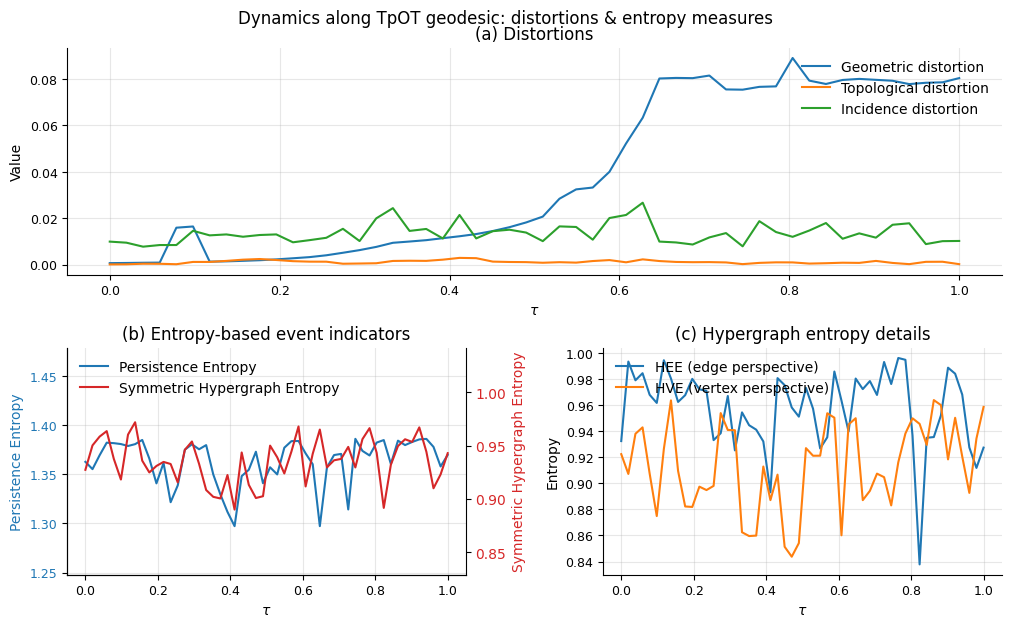

In [12]:
import numpy as np
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 6), constrained_layout=True)

gs = fig.add_gridspec(2, 2)

axA = fig.add_subplot(gs[0, :])

axB = fig.add_subplot(gs[1, 0])

axC = fig.add_subplot(gs[1, 1])

axA.plot(x/(num_frames-1), geom, label='Geometric distortion')
axA.plot(x/(num_frames-1), topo, label='Topological distortion')
axA.plot(x/(num_frames-1), hyper, label='Incidence distortion')
axA.set_title('(a) Distortions')
axA.set_xlabel(r'$\tau$')
axA.set_ylabel('Value')
axA.grid(True, alpha=0.3)
axA.legend(loc='upper right', ncol=1, frameon=False) # 图变宽了，Legend 放右上可能更好

color_left = 'tab:blue'
color_right = 'tab:red'

axB.plot(x/(num_frames-1), PE, color=color_left, label='Persistence Entropy')
axB.set_xlabel(r'$\tau$')
axB.set_ylabel('Persistence Entropy', color=color_left)
axB.tick_params(axis='y', labelcolor=color_left)
axB.grid(True, alpha=0.3)

axB_r = axB.twinx()
axB_r.plot(x/(num_frames-1), SHE, color=color_right, label='Symmetric Hypergraph Entropy')
axB_r.set_ylabel('Symmetric Hypergraph Entropy', color=color_right)
axB_r.tick_params(axis='y', labelcolor=color_right)

she_mean = np.nanmean(SHE)
she_range = np.nanmax(SHE) - np.nanmin(SHE)
pe_mean = np.nanmean(PE)
pe_range = np.nanmax(PE) - np.nanmin(PE)

if pe_range == 0: pe_range = 1.0
if she_range == 0: she_range = 1.0

axB.set_ylim(pe_mean - 1.3 * pe_range, pe_mean + 1.3 * pe_range)
axB_r.set_ylim(she_mean - 1.3 * she_range, she_mean + 1.3 * she_range)

axB.set_title('(b) Entropy-based event indicators') # 序号顺延改为 (b)

lines, labels = axB.get_legend_handles_labels()
lines2, labels2 = axB_r.get_legend_handles_labels()
axB.legend(lines + lines2, labels + labels2, loc='upper left', frameon=False)

axC.plot(x/(num_frames-1), HEE, label='HEE (edge perspective)')
axC.plot(x/(num_frames-1), HE, label='HVE (vertex perspective)')

axC.set_title('(c) Hypergraph entropy details') # 序号顺延改为 (c)
axC.set_xlabel(r'$\tau$')
axC.set_ylabel('Entropy')
axC.grid(True, alpha=0.3)
axC.legend(loc='upper left', ncol=1, frameon=False)

for ax in [axA, axB, axC]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if ax == axB:
        axB_r.spines['top'].set_visible(False)

    ax.tick_params(axis='both', which='major', labelsize=9)

fig.suptitle('Dynamics along TpOT geodesic: distortions & entropy measures', y=1.02)

plt.show()


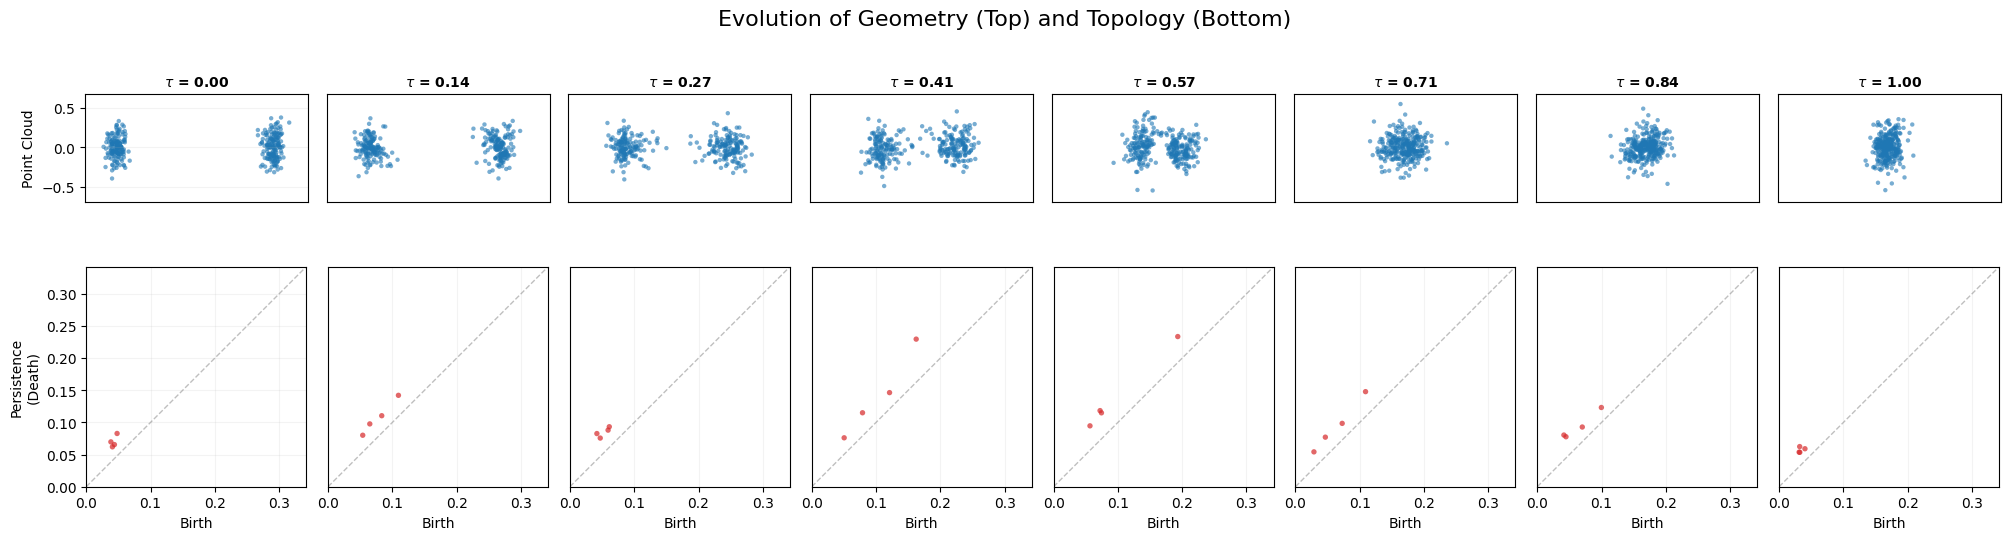

In [11]:
import numpy as np
import matplotlib.pyplot as plt

num_plots = 8  # 展示几列 (比如 8 个时间点)
total_frames = len(all_models_alligned)

indices = np.linspace(0, total_frames - 1, num_plots, dtype=int)

all_points_concat = np.vstack(all_models_alligned)
x_min, x_max = all_points_concat[:, 0].min(), all_points_concat[:, 0].max()
y_min, y_max = all_points_concat[:, 1].min(), all_points_concat[:, 1].max()

margin = 0.1
x_span = x_max - x_min
y_span = y_max - y_min
pc_xlim = (x_min - margin * x_span, x_max + margin * x_span)
pc_ylim = (y_min - margin * y_span, y_max + margin * y_span)

all_pd_concat = np.vstack([pd for pd in geodesic_pd if len(pd) > 0])
pd_max = np.max(all_pd_concat) * 1.1 if len(all_pd_concat) > 0 else 1.0
pd_lim = (0, pd_max)

fig, axes = plt.subplots(2, num_plots, figsize=(20, 5), constrained_layout=True)

for plot_idx, frame_idx in enumerate(indices):
    cloud = all_models_alligned[frame_idx]      # 形状 (N, 4)
    pd = geodesic_pd[frame_idx]    # 形状 (M, 2)
    t_val = frame_idx/(total_frames-1)

    ax_pc = axes[0, plot_idx]
    ax_pc.scatter(cloud[:, 0], cloud[:, 1], s=10, alpha=0.6, c='tab:blue', edgecolors='none')

    ax_pc.set_title(rf"$\tau$ = {t_val:.2f}", fontsize=10, fontweight='bold')
    ax_pc.set_xlim(pc_xlim)
    ax_pc.set_ylim(pc_ylim)
    ax_pc.set_aspect('equal')
    ax_pc.grid(True, alpha=0.15)

    ax_pd = axes[1, plot_idx]

    ax_pd.plot(pd_lim, pd_lim, c='gray', linestyle='--', linewidth=1, alpha=0.5)

    if len(pd) > 0:
        ax_pd.scatter(pd[:, 0], pd[:, 1], s=15, alpha=0.7, c='tab:red', edgecolors='none')

    ax_pd.set_xlim(pd_lim)
    ax_pd.set_ylim(pd_lim)
    ax_pd.set_aspect('equal')
    ax_pd.grid(True, alpha=0.15)

    if plot_idx == 0:
        ax_pc.set_ylabel("Point Cloud")
        ax_pd.set_ylabel("Persistence\n(Death)")
    else:
        ax_pc.set_yticks([])
        ax_pd.set_yticks([])

    ax_pc.set_xticks([])
    ax_pd.set_xlabel("Birth")

plt.suptitle("Evolution of Geometry (Top) and Topology (Bottom)", fontsize=16, y=1.05)
plt.show()
